## BASELINE MODELS


In [4]:
results_log = []  # accumulate all model results

def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl, store=True):
    """
    Fit model on X_tr / y_tr, evaluate on both train and val.
    Returns dict of metrics. Optionally appends to results_log.
    """

    model.fit(X_tr, y_tr)

    #  Predictions
    y_tr_pred = model.predict(X_tr)
    y_vl_pred = model.predict(X_vl)

    #  Metrics
    train_r2   = r2_score(y_tr, y_tr_pred)
    val_r2     = r2_score(y_vl, y_vl_pred)
    train_mae  = mean_absolute_error(y_tr, y_tr_pred)
    val_mae    = mean_absolute_error(y_vl, y_vl_pred)
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse   = np.sqrt(mean_squared_error(y_vl, y_vl_pred))

    #  Overfitting check
    overfit_gap  = train_r2 - val_r2
    overfit_flag = '⚠️ OVERFIT' if overfit_gap > 0.10 else '✅ OK'

    #  Result row
    row = {
        'Model': name,
        'Train R²': round(train_r2, 4),
        'Val R²':   round(val_r2,   4),
        'Train MAE': round(train_mae, 2),
        'Val MAE':   round(val_mae,   2),
        'Train RMSE': round(train_rmse, 2),
        'Val RMSE':   round(val_rmse,   2),
        'Overfit?': overfit_flag
    }

    #  Print summary
    print(f'  {name:<28}  Train R²={train_r2:.4f}  Val R²={val_r2:.4f}  '
          f'Val MAE={val_mae:.2f}  {overfit_flag}')

    #  Store results
    if store:
        results_log.append(row)

    return model, row

print('✅ evaluate_model() helper fixed and ready.')

✅ evaluate_model() helper fixed and ready.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 · Baseline Models — Linear, Ridge, Lasso, Random Forest
# ─────────────────────────────────────────────────────────────
# Why these baselines?
#   Linear Regression — simplest possible model; sets the floor.
#   Ridge             — linear + L2 regularisation (handles multicollinearity).
#   Lasso             — linear + L1 regularisation (performs feature selection).
#   Random Forest     — ensemble of trees; strong non-linear baseline.
#   These four tell us how much XGBoost actually improves over simpler methods.

print('Running baseline models...\n')

# 1. Linear Regression
lr_model, lr_res = evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_sc, y_train, X_val_sc, y_val
)

# 2. Ridge
ridge_model, ridge_res = evaluate_model(
    'Ridge (alpha=10)',
    Ridge(alpha=10, random_state=RANDOM_STATE),
    X_train_sc, y_train, X_val_sc, y_val
)

# 3. Lasso
lasso_model, lasso_res = evaluate_model(
    'Lasso (alpha=0.1)',
    Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
    X_train_sc, y_train, X_val_sc, y_val
)

# 4. Random Forest
rf_model, rf_res = evaluate_model(
    'Random Forest (100 trees)',
    RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_sc, y_train, X_val_sc, y_val
)

# 5. XGBoost baseline (FIXED)
xgb_base_model, xgb_base_res = evaluate_model(
    'XGBoost (baseline)',
    xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='mae',
        verbosity=0
    ),
    X_train_sc, y_train, X_val_sc, y_val
)

print()
print('Baseline Summary:')
display(pd.DataFrame(results_log))

Running baseline models...

  Linear Regression             Train R²=0.7345  Val R²=0.7437  Val MAE=32.96  ✅ OK
  Ridge (alpha=10)              Train R²=0.7344  Val R²=0.7435  Val MAE=32.97  ✅ OK
  Lasso (alpha=0.1)             Train R²=0.7341  Val R²=0.7429  Val MAE=33.01  ✅ OK
  Random Forest (100 trees)     Train R²=0.9429  Val R²=0.8795  Val MAE=20.66  ✅ OK
  XGBoost (baseline)            Train R²=0.9685  Val R²=0.9080  Val MAE=17.99  ✅ OK

Baseline Summary:


,Model,Train R²,Val R²,Train MAE,Val MAE,Train RMSE,Val RMSE,Overfit?
0,Linear Regression,0.7345,0.7437,32.40,32.96,39.94,39.88,✅ OK
1,Ridge (alpha=10),0.7344,0.7435,32.40,32.97,39.94,39.90,✅ OK
2,Lasso (alpha=0.1),0.7341,0.7429,32.44,33.01,39.96,39.94,✅ OK
3,Random Forest (100 trees),0.9429,0.8795,14.05,20.66,18.52,27.35,✅ OK
4,XGBoost (baseline),0.9685,0.9080,10.83,17.99,13.76,23.89,✅ OK


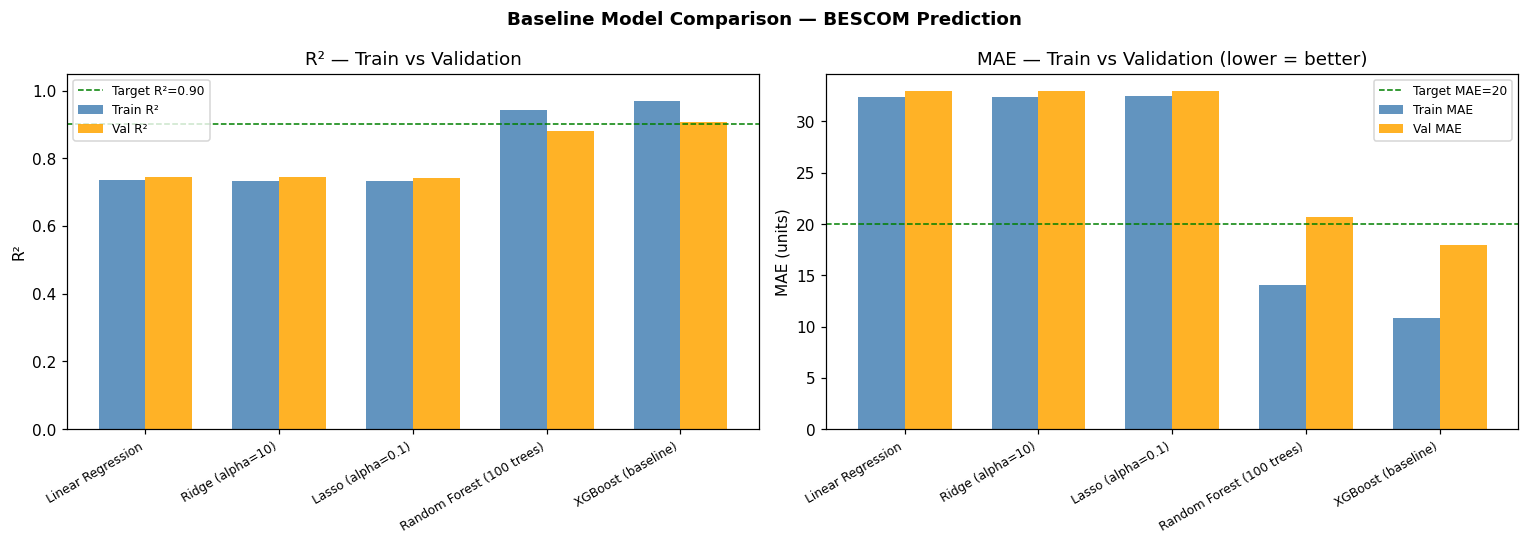

Observation:
  Best Val R²  → XGBoost (baseline) : 0.9080
  Best Val MAE → XGBoost (baseline) : 17.99 units


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 · Baseline Comparison Plot
# ─────────────────────────────────────────────────────────────
baseline_df = pd.DataFrame(results_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_  = baseline_df['Model']
x_pos    = np.arange(len(models_))
bar_w    = 0.35

# R² comparison
ax = axes[0]
ax.bar(x_pos - bar_w/2, baseline_df['Train R²'], bar_w,
       label='Train R²', color='steelblue', alpha=0.85)
ax.bar(x_pos + bar_w/2, baseline_df['Val R²'],   bar_w,
       label='Val R²',   color='orange',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(models_, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('R² — Train vs Validation')
ax.axhline(0.90, color='green',  ls='--', lw=1, label='Target R²=0.90')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# MAE comparison
ax2 = axes[1]
ax2.bar(x_pos - bar_w/2, baseline_df['Train MAE'], bar_w,
        label='Train MAE', color='steelblue', alpha=0.85)
ax2.bar(x_pos + bar_w/2, baseline_df['Val MAE'],   bar_w,
        label='Val MAE',   color='orange',    alpha=0.85)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('MAE (units)')
ax2.set_title('MAE — Train vs Validation (lower = better)')
ax2.axhline(20, color='green', ls='--', lw=1, label='Target MAE=20')
ax2.legend(fontsize=8)

plt.suptitle('Baseline Model Comparison — BESCOM Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation:')
best_val_r2 = baseline_df.loc[baseline_df['Val R²'].idxmax()]
print(f'  Best Val R²  → {best_val_r2["Model"]} : {best_val_r2["Val R²"]:.4f}')
best_val_mae = baseline_df.loc[baseline_df['Val MAE'].idxmin()]
print(f'  Best Val MAE → {best_val_mae["Model"]} : {best_val_mae["Val MAE"]:.2f} units')